In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# load file
df = pd.read_csv("zara_combined_men_women_kids.csv")

# quick look
print(df.head())
print(df.columns.tolist())
print(df.shape)

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [4]:
def product_type(name, source=""):
    s = (str(name) + " " + str(source)).lower()
    if any(k in s for k in ["loafer", "shoe", "sandal", "boot", "mule", "sneaker", "heel", "ballet", "espadrille"]):
        return "Footwear"
    if any(k in s for k in ["bag", "wallet", "belt", "cap", "hat", "scarf", "tie", "sunglasses", "necklace", "earring"]):
        return "Accessory"
    if any(k in s for k in ["jacket", "blazer", "parka", "coat", "outerwear", "overshirt", "suit"]):
        return "Outerwear"
    if any(k in s for k in ["pants", "trouser", "trousers", "jean", "shorts", "legging", "jogger"]):
        return "Bottoms"
    if any(k in s for k in ["dress", "skirt"]):
        return "Dress/Skirt"
    if any(k in s for k in ["shirt", "polo", "t-shirt", "t shirt", "tee", "top", "blouse", "henley", "sweater", "cardigan", "vest", "knit", "hoodie", "sweatshirt"]):
        return "Top"
    return "Other"

df["product_type"] = df.apply(lambda r: product_type(r["name"], r["Source File"]), axis=1)

mat = df["materials_text"].fillna("").str.lower()

patterns = {
    "recycled_flag": r"recycled",
    "organic_flag": r"organic|organically",
    "linen_flag": r"linen",
    "cotton_flag": r"cotton",
    "polyester_flag": r"polyester",
    "viscose_flag": r"viscose",
    "silk_flag": r"silk",
    "wool_flag": r"wool",
}

for col, pattern in patterns.items():
    df[col] = mat.str.contains(pattern, regex=True).astype(int)

# stack US and India into one long dataset
us = df[[
    "Product_ID", "name", "Segment", "product_type", "US_price_current_usd",
    "recycled_flag", "organic_flag", "linen_flag", "cotton_flag",
    "polyester_flag", "viscose_flag", "silk_flag", "wool_flag"
]].copy()
us = us.rename(columns={"US_price_current_usd": "price_usd"})
us["country"] = "US"

india = df[[
    "Product_ID", "name", "Segment", "product_type", "IN_price_current_usd",
    "recycled_flag", "organic_flag", "linen_flag", "cotton_flag",
    "polyester_flag", "viscose_flag", "silk_flag", "wool_flag"
]].copy()
india = india.rename(columns={"IN_price_current_usd": "price_usd"})
india["country"] = "India"

long = pd.concat([us, india], ignore_index=True)
long = long.dropna(subset=["price_usd"]).copy()
long["log_price"] = np.log(long["price_usd"])

# direct US - India price gap
gap_df = df.dropna(subset=["US_price_current_usd", "IN_price_current_usd"]).copy()
gap_df["price_gap_usd"] = gap_df["US_price_current_usd"] - gap_df["IN_price_current_usd"]

print(long.head())
print(gap_df[["name", "US_price_current_usd", "IN_price_current_usd", "price_gap_usd"]].head())

NameError: name 'df' is not defined

In [ ]:
# main price model
stacked_model = smf.ols(
    "log_price ~ C(country) + recycled_flag + C(country):recycled_flag + organic_flag + linen_flag + cotton_flag + polyester_flag + viscose_flag + silk_flag + wool_flag + C(Segment) + C(product_type)",
    data=long
).fit(cov_type="cluster", cov_kwds={"groups": long["Product_ID"]})

print(stacked_model.summary())

# US minus India price gap model
gap_model = smf.ols(
    "price_gap_usd ~ recycled_flag + organic_flag + linen_flag + cotton_flag + polyester_flag + viscose_flag + silk_flag + wool_flag + C(Segment) + C(product_type)",
    data=gap_df
).fit()

print(gap_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     170.1
Date:                Sat, 11 Apr 2026   Prob (F-statistic):          7.00e-220
Time:                        19:47:33   Log-Likelihood:                -625.57
No. Observations:                1059   AIC:                             1289.
Df Residuals:                    1040   BIC:                             1383.
Df Model:                          18                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

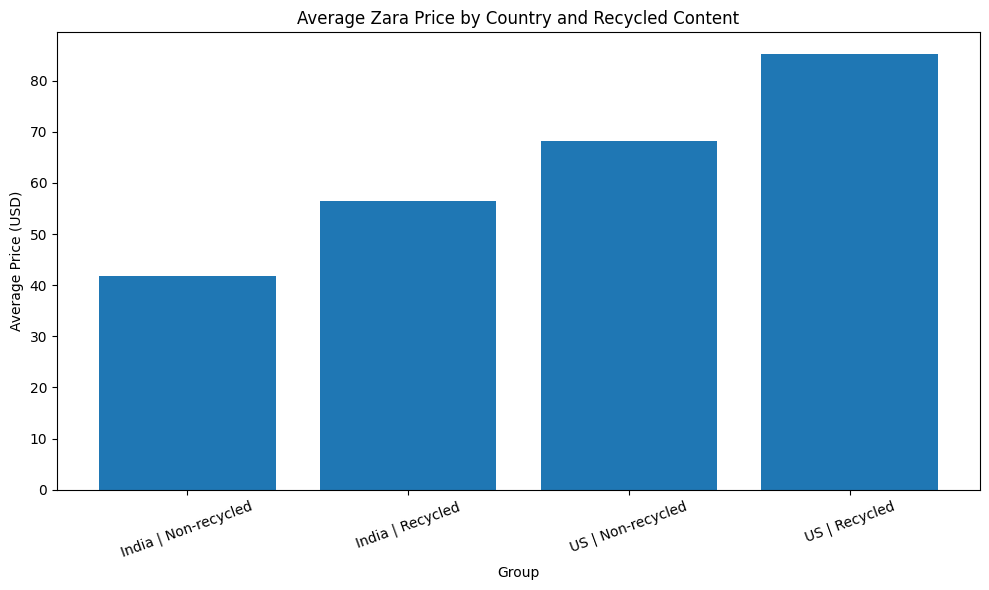

In [ ]:
summary = (
    long.groupby(["country", "recycled_flag"])["price_usd"]
    .mean()
    .reset_index()
)

summary["label"] = summary["country"] + " | " + summary["recycled_flag"].map({
    0: "Non-recycled",
    1: "Recycled"
})

plt.figure(figsize=(10,6))
plt.bar(summary["label"], summary["price_usd"])
plt.title("Average Zara Price by Country and Recycled Content")
plt.xlabel("Group")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

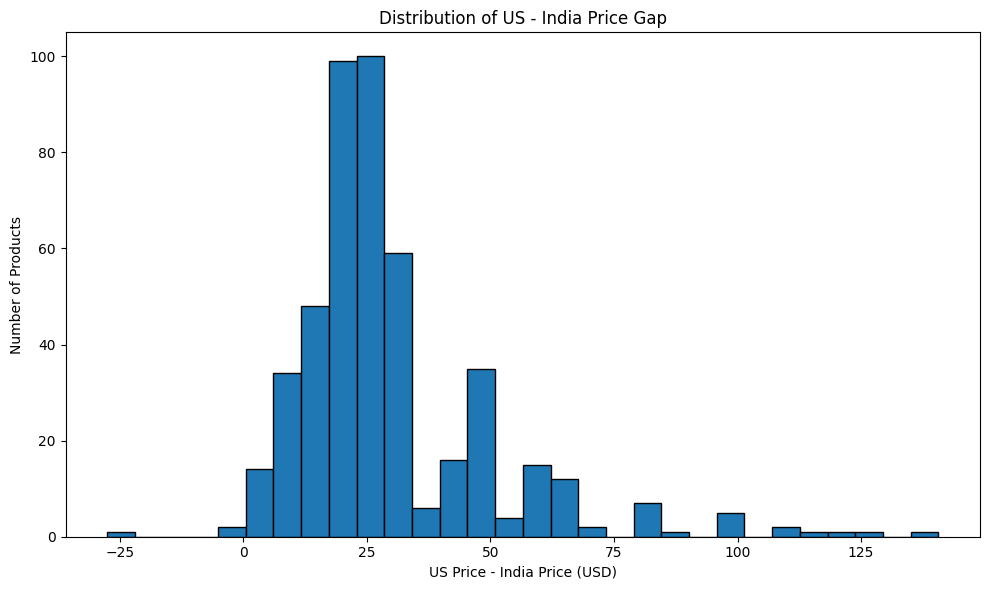

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(gap_df["price_gap_usd"], bins=30, edgecolor="black")
plt.title("Distribution of US - India Price Gap")
plt.xlabel("US Price - India Price (USD)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

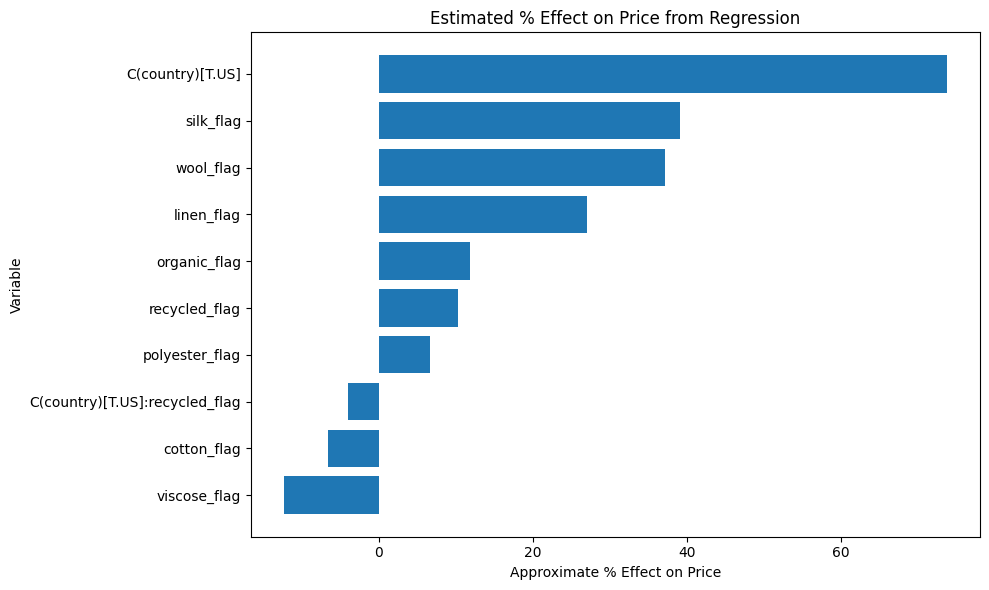

                              term      coef        p_value  pct_effect
16                    viscose_flag -0.131503   4.011068e-02  -12.322355
14                     cotton_flag -0.068430   1.729108e-01   -6.614128
11  C(country)[T.US]:recycled_flag -0.041356   1.142374e-01   -4.051255
15                  polyester_flag  0.063574   1.954445e-01    6.563813
10                   recycled_flag  0.097663   3.739133e-02   10.259142
12                    organic_flag  0.112217   9.381073e-03   11.875599
13                      linen_flag  0.238907   1.983489e-05   26.986021
18                       wool_flag  0.315579   8.406906e-03   37.105326
17                       silk_flag  0.329598   5.045440e-01   39.040919
1                 C(country)[T.US]  0.552277  2.479654e-203   73.720448


In [ ]:
coef = pd.DataFrame({
    "term": stacked_model.params.index,
    "coef": stacked_model.params.values,
    "p_value": stacked_model.pvalues.values
})

# keep the main terms only
wanted = [
    "C(country)[T.US]",
    "recycled_flag",
    "C(country)[T.US]:recycled_flag",
    "organic_flag",
    "linen_flag",
    "cotton_flag",
    "polyester_flag",
    "viscose_flag",
    "silk_flag",
    "wool_flag"
]

coef = coef[coef["term"].isin(wanted)].copy()
coef["pct_effect"] = (np.exp(coef["coef"]) - 1) * 100
coef = coef.sort_values("pct_effect")

plt.figure(figsize=(10,6))
plt.barh(coef["term"], coef["pct_effect"])
plt.title("Estimated % Effect on Price from Regression")
plt.xlabel("Approximate % Effect on Price")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

print(coef)

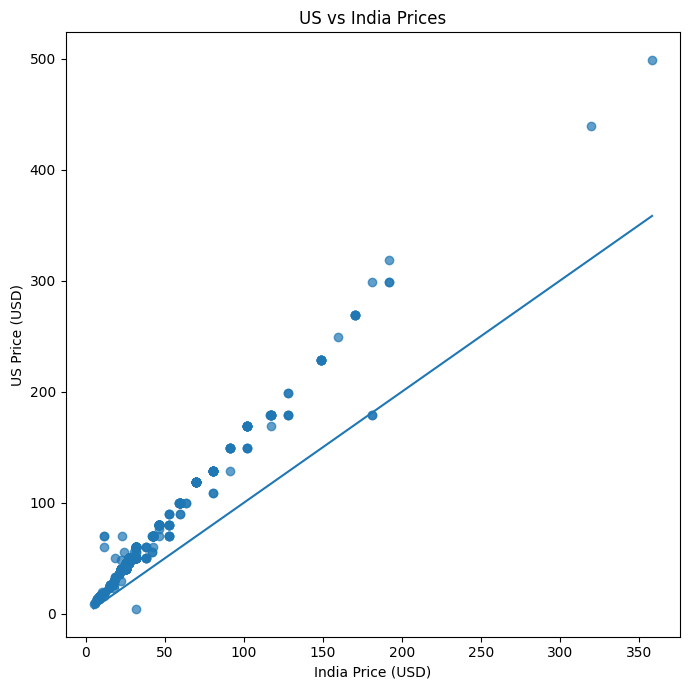

In [ ]:
matched = df.dropna(subset=["US_price_current_usd", "IN_price_current_usd"]).copy()

plt.figure(figsize=(7,7))
plt.scatter(matched["IN_price_current_usd"], matched["US_price_current_usd"], alpha=0.7)
plt.plot(
    [matched["IN_price_current_usd"].min(), matched["IN_price_current_usd"].max()],
    [matched["IN_price_current_usd"].min(), matched["IN_price_current_usd"].max()]
)
plt.title("US vs India Prices")
plt.xlabel("India Price (USD)")
plt.ylabel("US Price (USD)")
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# 1. LOAD DATA
# =========================
file_path = "your_file.csv"   # <-- change this
df = pd.read_csv(file_path)

# =========================
# 2. CLEAN COLUMN NAMES
# =========================
df.columns = [c.strip().lower() for c in df.columns]

# =========================
# 3. CHANGE THESE TO MATCH YOUR FILE
# =========================
target_col = "price_original_inr"   # or "price_original_usd"
country_col = "country"
brand_col = "brand"
made_in_col = "made_in"
category_col = "category"
material_count_col = "material_count"
rcs_col = "rcs"
ocs_col = "ocs"

# =========================
# 4. FILTER TO INDIA
# =========================
# adjust this depending on how India is stored in your dataset
india_df = df[df[country_col].astype(str).str.lower().str.contains("india", na=False)].copy()

# =========================
# 5. COERCE NUMERIC / BOOLEAN
# =========================
def to_binary(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "1": 1, "0": 0,
            "true": 1, "false": 0,
            "yes": 1, "no": 0
        })
    )

india_df[rcs_col] = to_binary(india_df[rcs_col])
india_df[ocs_col] = to_binary(india_df[ocs_col])

india_df[material_count_col] = pd.to_numeric(india_df[material_count_col], errors="coerce")
india_df[target_col] = pd.to_numeric(india_df[target_col], errors="coerce")

# =========================
# 6. DROP ROWS MISSING TARGET
# =========================
india_df = india_df.dropna(subset=[target_col])

# =========================
# 7. SELECT FEATURES
# =========================
numeric_features = [rcs_col, ocs_col, material_count_col]
categorical_features = [brand_col, made_in_col, category_col]

X = india_df[numeric_features + categorical_features].copy()
y = india_df[target_col].copy()

# =========================
# 8. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 9. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# =========================
# 10. MODEL
# =========================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# =========================
# 11. FIT
# =========================
pipeline.fit(X_train, y_train)

# =========================
# 12. PREDICT
# =========================
y_pred = pipeline.predict(X_test)

# =========================
# 13. METRICS
# =========================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE")
print("-----------------")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# =========================
# 14. PREDICTIONS TABLE
# =========================
results = X_test.copy()
results["actual_price"] = y_test.values
results["predicted_price"] = y_pred
results["error"] = results["actual_price"] - results["predicted_price"]

print("\nSAMPLE PREDICTIONS")
print("------------------")
print(results.head(10))

# =========================
# 15. FEATURE IMPORTANCE
# =========================
# get feature names after one-hot encoding
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

importances = pipeline.named_steps["model"].feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTOP FEATURE IMPORTANCES")
print("-----------------------")
print(feature_importance_df.head(20))

# =========================
# 16. SAVE OUTPUTS
# =========================
results.to_csv("india_price_predictions.csv", index=False)
feature_importance_df.to_csv("india_feature_importance.csv", index=False)

print("\nSaved:")
print(" - india_price_predictions.csv")
print(" - india_feature_importance.csv")

KeyboardInterrupt: 

In [5]:
# =====================================
# FINAL PRICE PREDICTION MODEL + GRAPHS
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1) COPY DATA
# -----------------------------

df_model = df.copy()

print("Initial rows:", len(df_model))

# -----------------------------
# 2) CREATE RCS / OCS FLAGS
# -----------------------------

df_model["rcs"] = (
    df_model["materials_text"]
    .astype(str)
    .str.contains("rcs", case=False, na=False)
    .astype(int)
)

df_model["ocs"] = (
    df_model["materials_text"]
    .astype(str)
    .str.contains("ocs", case=False, na=False)
    .astype(int)
)

# -----------------------------
# 3) ENSURE NUMERIC PRICE
# -----------------------------

df_model["IN_price_current_inr"] = pd.to_numeric(
    df_model["IN_price_current_inr"],
    errors="coerce"
)

df_model = df_model.dropna(subset=["IN_price_current_inr"])

print("Rows after cleaning:", len(df_model))

# -----------------------------
# 4) SAFE FEATURE LIST
# -----------------------------

features = [
    "rcs",
    "ocs",
    "material_count",
    "brand",
    "Category",
    "made_in",
    "Segment"
]

features = [f for f in features if f in df_model.columns]

print("Features used:", features)

target = "IN_price_current_inr"

X = df_model[features]
y = df_model[target]

# -----------------------------
# 5) CONVERT CATEGORICALS
# -----------------------------

X = pd.get_dummies(X, drop_first=True)

# -----------------------------
# 6) TRAIN / TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 7) LINEAR REGRESSION
# -----------------------------

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# -----------------------------
# 8) RANDOM FOREST
# -----------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# -----------------------------
# 9) METRICS
# -----------------------------

def evaluate(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("\n", name)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 3))

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

# -----------------------------
# 10) ACTUAL VS PREDICTED
# -----------------------------

plt.figure()

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual India Price")
plt.ylabel("Predicted India Price")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

plt.figure()

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual India Price")
plt.ylabel("Predicted India Price")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

# -----------------------------
# 11) RESIDUAL PLOT
# -----------------------------

residuals = y_test - lr_pred

plt.figure()

plt.scatter(lr_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# -----------------------------
# 12) FEATURE IMPORTANCE
# -----------------------------

importance = pd.DataFrame({

    "feature": X.columns,
    "importance": rf.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
).head(15)

plt.figure()

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")

plt.title("Top Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# -----------------------------
# 13) RCS / OCS EFFECT
# -----------------------------

coef_df = pd.DataFrame({

    "feature": X.columns,
    "coefficient": lr.coef_

})

print("\nTop coefficients:")

print(
    coef_df.sort_values(
        "coefficient",
        key=abs,
        ascending=False
    ).head(10)
)

# Save results

coef_df.to_csv(
    "linear_regression_coefficients.csv",
    index=False
)

importance.to_csv(
    "random_forest_importance.csv",
    index=False
)

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)